# Import the necessary packages

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import pathlib 
import os
import scimap as sm
from utils.delaunay_graph import delaunay_adata_internal, delaunay_adata
from utils.cluster_stability import cluster_stability_calculate
from utils.celltype_enrichment_niche import nhood_enrichment
import anndata as ad

# Paths

In [4]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"

# Color palette

In [10]:
myeloid_palette = {
    "MDSCs": "#332288",
    "M2 macrophages": "#66A61E",
    "M1 macrophages": "#00557F",
    "M1/M2 macrophages": "#BBCCEE",
    "DCs": "#E69F00",
    "Granulocytes": "#B85AA6",
    "Mast cells": "#8E006A",
}
lymphoid_palette = {
    "CD8+ T cells": "#B2182B",
    "CD4+ T cells": "#EF8A62",
    "Treg T cells": "#FFCCCC",
    "NK cells": "#0096FF",
    "B cells": "#E6C84F",
    "PCs": "#F4E58A",
}
non_immune_palette = {
    "Actin+ cells": "#B39DDB",
    "Endothelial cells": "#00BFC4",
    "Lymphatic endothelial cells": "#1F78B4",
    "Epithelial cells": "#C9B29B",
}
other_palette = {
    "Tumor cells": "#44AA99",
    "NFC": "#DDDDDD",
}
full_palette = {
    **myeloid_palette,
    **lymphoid_palette,
    **non_immune_palette,
    **other_palette,
}

# Loading the required data

In [5]:
adata = sc.read_h5ad(os.path.join(data_dir, "adata.h5ad"))

# Creating delaunay graphs for the ROIs

In [6]:
adata = delaunay_adata(adata, 
                       coords_key="spatial", 
                       phenotype="cell_category", 
                       image_id="patient_exp", 
                       label="spatial_count_delaunay")

## Get the confusion matrix of the neighbors

In [7]:
adata.uns["spatial_prop_delaunay"] = adata.uns["spatial_count_delaunay"].div(adata.uns["spatial_count_delaunay"].sum(axis=1), axis=0)

In [8]:
adata.uns["spatial_prop_delaunay"]

neighbour_phenotype,Actin+ cells,B cells,CD4+ T cells,CD8+ T cells,DCs,Endothelial cells,Granulocytes,Lymphatic endothelial cells,M1 macrophages,M1/M2 macrophages,M2 macrophages,MDSCs,Mast cells,NFC,NK cells,PCs,Treg T cells,Tumor cells,Epithelial cells
378930,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66114,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66113,0.111111,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.222222,0.0,0.0,0.0,0.666667,0.0
66112,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66111,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.142857,0.285714,0.000000,0.000000,0.0,0.142857,0.0,0.0,0.0,0.428571,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420571,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.400000,0.0,0.0,0.0,0.600000,0.0
420572,0.000000,0.0,0.4,0.6,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
420573,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.400000,0.0,0.0,0.0,0.600000,0.0
420564,0.000000,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0


In [9]:
best_k, best_score, results_df = cluster_stability_calculate(
    adata,
    uns_key="spatial_prop_delaunay",
    k_min=8,
    k_max=18,
    n_repeats=10,        # increase to 8–10 if you want more robustness
    sample_size=50000,  # safe for your 560k dataset
    random_state=196979
)

k=8 | mean ARI=0.9608
k=9 | mean ARI=0.9175
k=10 | mean ARI=0.9442
k=11 | mean ARI=0.9646
k=12 | mean ARI=0.9654
k=13 | mean ARI=0.8720
k=14 | mean ARI=0.7272
k=15 | mean ARI=0.8711
k=16 | mean ARI=0.9021
k=17 | mean ARI=0.8265
k=18 | mean ARI=0.8638


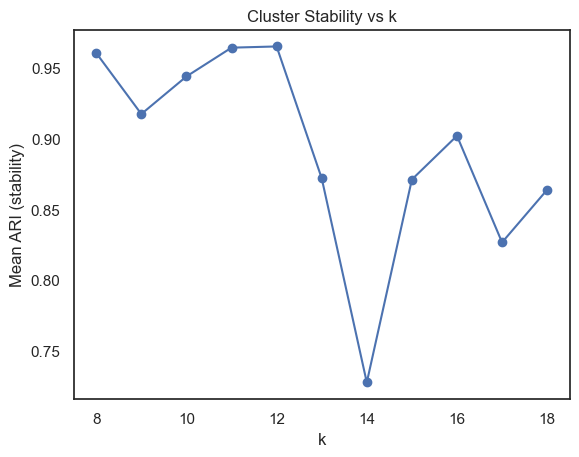

In [11]:
#showcase cluster stability analysis results
plt.figure()
plt.plot(results_df.index, results_df["mean_ARI"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean ARI (stability)")
plt.title("Cluster Stability vs k")
plt.show()

In [28]:
#save the results of cluster stability analysis
results_df.to_csv(os.path.join(data_dir, "cluster_stability_results.csv"), index=True)

## k = 12

In [12]:
adata = sm.tl.spatial_cluster(adata, 
                              df_name='spatial_prop_delaunay', 
                              method='kmeans', 
                              k=12, 
                              label='neigh_kmeans_count', 
                              random_state=196979)

Kmeans clustering


In [13]:
sm.pl.stacked_barplot(adata, 
                      x_axis='neigh_kmeans_count', 
                      y_axis='cell_category', 
                      plot_tool='plotly', 
                      color_discrete_map = full_palette)

In [23]:
#mix clustters 4 and 9 since they are similar in composition and define the clusters as follows:
cluster_to_name = {
    0: "Lymphatic_immune",
    1: "Tumor_bulk",
    2: "Tumor_NFC",
    3: "Stromal_fibroblasts",
    4: "Myeloid_granulocytic",
    5: "Epithelial_adjacent",
    6: "Vascular/Endothelial",
    7: "Lymphoid_B",
    8: "TLS",
    9: "Tumor_myeloid",
    10: "Lymphoid_T",
    11:"Stromal_NFC"
}
#make neigh_kmeans integers first
adata.obs["neigh_kmeans_count"] = adata.obs["neigh_kmeans_count"].astype(int)
adata.obs["neighborhood"] = adata.obs["neigh_kmeans_count"].map(cluster_to_name)

In [24]:
nhood_enrichment(
    adata,
    group_key="cell_category",
    label_key="neighborhood",
    log=True,
    pvalues=True, 
)

100%|██████████| 200/200 [00:12<00:00, 16.07it/s]


In [25]:
adata.uns.keys()

odict_keys(['spatial_count_delaunay', 'spatial_prop_delaunay', 'neigh_kmeans_count_cell_category_enrichment', 'neighborhood_cell_category_enrichment'])

In [27]:
enr = adata.uns["neighborhood_cell_category_enrichment"]["enrichment"]
pvalues = adata.uns["neighborhood_cell_category_enrichment"]["pvalue"]

neighborhood,Epithelial_adjacent,Lymphatic_immune,Lymphoid_B,Lymphoid_T,Myeloid_granulocytic,Stromal_NFC,Stromal_fibroblasts,TLS,Tumor_NFC,Tumor_bulk,Tumor_myeloid,Vascular/Endothelial
cell_category,,,,,,,,,,,,
Actin+ cells,-3.914149,-0.165189,-1.035790,-0.457656,-1.889094,-0.571230,3.026528,0.314577,-1.085792,-2.721717,-0.405071,0.467752
B cells,-4.051590,0.507073,5.402682,0.689921,-2.322460,-2.577479,-0.425565,1.664121,-2.761971,-3.105316,-1.928854,-1.184037
CD4+ T cells,-2.710905,0.654883,1.365768,2.317427,-1.350463,-1.047482,0.045889,3.668307,-2.076402,-4.014485,-1.895652,-0.769814
CD8+ T cells,-0.894583,0.411652,0.237223,3.989999,-1.072049,-1.392039,-0.523535,2.489554,-1.968571,-2.861069,-1.186713,-0.977257
DCs,-0.088956,2.138899,-0.876173,1.058082,0.451563,-0.145512,-0.406487,0.873468,-0.917603,-1.079781,0.028608,-1.235031
Endothelial cells,-2.159871,-0.007622,-1.748193,-1.355388,-1.564245,-0.232911,0.276215,-0.842593,-0.985185,-3.339453,-0.772331,3.881730
Epithelial cells,5.275529,-1.563135,-5.171477,-1.913697,-0.528988,-2.065724,-3.596171,-4.674238,-1.167646,-2.964664,-1.172023,-1.960256
Granulocytes,-0.218178,0.102989,-2.967304,-0.881196,3.776914,-0.937328,-1.152138,-1.740251,-1.121565,-2.038686,0.257311,-0.873995
Lymphatic endothelial cells,-0.592772,3.265182,0.324432,-0.411450,-1.392486,-0.455795,-0.975848,-0.013834,-1.200339,-3.108498,-0.468782,-0.636846


## Save the enrichment and the pvalues

In [29]:
enr.to_csv(os.path.join(data_dir, "neighborhood_cell_category_enrichment.csv"), index=True)
pvalues.to_csv(os.path.join(data_dir, "neighborhood_cell_category_enrichment_pvalues.csv"), index=True)

# Finally save the anndata with the neighborhoods

In [32]:
#save anndata
adata.write_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))